# SVM — Pseudoalgoritmos com Exemplos Numéricos

---

## Índice

1. Conceitos fundamentais e glossário
2. Dataset de exemplo (4 pontos, 2 classes)
3. **Algoritmo 1 — SVM Linear** (sem kernel)  
   Fases 1→7 com fórmulas, notas e código
4. **Algoritmo 2 — SVM Kernelizado**  
   Fases 1→6 com kernel RBF, fórmulas e código
5. Comparação lado a lado
6. Visualizações completas

---

## 1. Conceitos fundamentais e glossário

| Símbolo | Significado | Papel no algoritmo |
|---|---|---|
| $x_i \in \mathbb{R}^p$ | vetor de features da amostra $i$ | **constante** — vem dos dados |
| $y_i \in \{-1, +1\}$ | rótulo da classe | **constante** — vem dos dados |
| $n$ | número de amostras | **constante** |
| $p$ | número de features | **constante** |
| $C$ | hiperparâmetro de regularização | **constante** — você define |
| $w \in \mathbb{R}^p$ | vetor normal ao hiperplano | **variável de decisão** (Alg. 1) |
| $b \in \mathbb{R}$ | bias (intercepto) | **variável de decisão** |
| $\xi_i \in \mathbb{R}^+$ | folga do ponto $i$ (soft margin) | **variável de decisão** |
| $\alpha_i \geq 0$ | multiplicador de Lagrange | **variável dual** — emerge do QP |
| $Q_{ij}$ | elemento da matriz dual | $y_i y_j (x_i \cdot x_j)$ |
| SVs | vetores de suporte | pontos com $\alpha_i^* > 0$ **após** o QP |
| $\gamma$ | margem geométrica | $2 / \|w^*\|$ |
| $f(x)$ | score funcional | $w^* \cdot x + b^*$ |
| $d(x)$ | distância ao hiperplano | $|f(x)| / \|w^*\|$ |

### Regras de classificação

$$\hat{y} = \text{sinal}(f(x)) = \begin{cases} +1 & \text{se } w \cdot x + b > 0 \\ -1 & \text{se } w \cdot x + b < 0 \end{cases}$$

### Por que os SVs não são o primeiro passo?

Antes de rodar o algoritmo, **qualquer** ponto poderia ser um SV.  
A identificação dos SVs é **consequência** da otimização — não entrada.

```
Antes do QP:  todos os n pontos são candidatos
Durante o QP: αᵢ sobe de 0 para > 0 nos pontos "difíceis"
Após o QP:    αᵢ* > ε  →  SV      (contribui para o modelo)
              αᵢ* = 0  →  normal   (descartado — αᵢ = 0 cancela na soma)
```

---

## 2. Dataset de exemplo

Usaremos 4 pontos em $\mathbb{R}^2$ ao longo de todo o notebook para ilustrar cada passo:

| Ponto | $x_1$ | $x_2$ | Classe $y_i$ |
|---|---|---|---|
| A | 1 | 2 | +1 |
| B | 2 | 1 | +1 |
| C | −1 | −1 | −1 |
| D | −2 | 0 | −1 |

Classes balanceadas (2 por classe). Dataset linearmente separável.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# Dataset de exemplo
X = np.array([[1., 2.], [2., 1.], [-1., -1.], [-2., 0.]])
y = np.array([1., 1., -1., -1.])
nomes = ['A', 'B', 'C', 'D']

print("Dataset:")
print(f"  {'Ponto':<8} {'x1':>6} {'x2':>6} {'classe':>8}")
print("  " + "─"*32)
for nome, xi, yi in zip(nomes, X, y):
    print(f"  {nome:<8} {xi[0]:>6.1f} {xi[1]:>6.1f} {int(yi):+8d}")

Dataset:
  Ponto        x1     x2   classe
  ────────────────────────────────
  A           1.0    2.0       +1
  B           2.0    1.0       +1
  C          -1.0   -1.0       -1
  D          -2.0    0.0       -1


---

## 3. Algoritmo 1 — SVM Linear (sem kernel)

```
ALGORITMO: SVM Linear — todos os passos
════════════════════════════════════════════════════════════════════════

ENTRADA:
  D = {(x₁,y₁), ..., (xₙ,yₙ)}   yᵢ ∈ {-1, +1}
  C   parâmetro de regularização  (C → ∞ = hard margin)

SAÍDA:
  w*   vetor normal do hiperplano ótimo  ∈ ℝᵖ
  b*   bias ótimo                        ∈ ℝ
  SVs  vetores de suporte (saída, não entrada!)
  γ    margem geométrica

COMPLEXIDADE TOTAL: O(n²·p) a O(n³)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╔══════════════════════════════════════════════════════════════════════╗
║  FASE 1 — PRÉ-PROCESSAMENTO                    O(n·p)                ║
╚══════════════════════════════════════════════════════════════════════╝

  PASSO 1.1 — Normalizar features
  ┌──────────────────────────────────────────────────────────────────┐
  │  Para cada feature j = 1..p:                                     │
  │    μⱼ ← (1/n) Σᵢ xᵢⱼ          (média, calculada NO TREINO)       │
  │    σⱼ ← √[(1/n) Σᵢ (xᵢⱼ−μⱼ)²] (desvio, calculado NO TREINO)      │
  │    xᵢⱼ ← (xᵢⱼ − μⱼ) / σⱼ      (aplicar em treino E em teste)     │
  │                                                                  │
  │  MOTIVO: ‖w‖² soma todas as dimensões igualmente.                │
  │  Feature em escala 1000× domina o gradiente sem justificativa.   │
  │  Guardar μ e σ para normalizar dados novos na predição.          │
  └──────────────────────────────────────────────────────────────────┘

╔══════════════════════════════════════════════════════════════════════╗
║  FASE 2 — MONTAGEM DO PROBLEMA                 O(n²·p)               ║
╚══════════════════════════════════════════════════════════════════════╝

  PASSO 2.1 — Definir variáveis de decisão
  ┌──────────────────────────────────────────────────────────────────┐
  │  w ∈ ℝᵖ    incógnita — o vetor normal que queremos achar         │
  │  b ∈ ℝ     incógnita — o bias                                    │
  │  ξᵢ ∈ ℝ⁺   incógnita — folga de cada ponto (soft margin)         │
  │                                                                  │
  │  xᵢ e yᵢ são CONSTANTES (dados já fixos).                        │
  │  w e b são INCÓGNITAS — como x numa equação.                     │
  └──────────────────────────────────────────────────────────────────┘

  PASSO 2.2 — Escrever o problema primal
  ┌──────────────────────────────────────────────────────────────────┐
  │  Minimizar:   (1/2)‖w‖²  +  C · Σᵢ ξᵢ                            │
  │                                                                  │
  │  Sujeito a:   yᵢ(w·xᵢ + b) ≥ 1 − ξᵢ    ∀i = 1..n                 │
  │               ξᵢ ≥ 0                     ∀i = 1..n               │
  │                                                                  │
  │  Substitui os dados:                                             │
  │  → cada restrição tem xᵢ e yᵢ fixos, w e b variáveis             │
  │  → gera um QP (Quadratic Program) com n restrições               │
  └──────────────────────────────────────────────────────────────────┘

  PASSO 2.3 — Derivar o dual de Lagrange
  ┌──────────────────────────────────────────────────────────────────┐
  │  Condições KKT (∂ℒ/∂w = 0, ∂ℒ/∂b = 0, ∂ℒ/∂ξᵢ = 0):              │
  │    (KKT-1)  w = Σᵢ αᵢ yᵢ xᵢ                                      │
  │    (KKT-2)  Σᵢ αᵢ yᵢ = 0                                         │
  │    (KKT-3)  0 ≤ αᵢ ≤ C                                           │
  │                                                                  │
  │  Problema dual (substitui KKT-1 no Lagrangiano):                 │
  │    Maximizar:  Σᵢ αᵢ − (1/2) Σᵢⱼ αᵢαⱼ yᵢyⱼ (xᵢ·xⱼ)               │
  │    Sujeito a:  0 ≤ αᵢ ≤ C   e   Σᵢ αᵢ yᵢ = 0                     │
  └──────────────────────────────────────────────────────────────────┘

  PASSO 2.4 — Montar a matriz Q   (TODOS os n pontos)
  ┌──────────────────────────────────────────────────────────────────┐
  │  Q[i,j] ← yᵢ · yⱼ · (xᵢ · xⱼ)   para todo par (i,j)              │
  │                                                                  │
  │  Dimensão: n × n  (com 8 pontos → 8×8 = 64 entradas)             │
  │  Propriedades: simétrica (Q[i,j]=Q[j,i]) e semidefinida positiva │
  │                                                                  │
  │  TODOS os n pontos entram aqui — sem exceção.                    │
  │  Neste momento não se sabe quais vão ser SVs.                    │
  │  Os SVs só serão conhecidos APÓS a fase 3.                       │
  │                                                                  │
  │  Memória: O(n²)  →  n=10.000 já ocupa ~800 MB                    │
  └──────────────────────────────────────────────────────────────────┘

╔══════════════════════════════════════════════════════════════════════╗
║  FASE 3 — OTIMIZAÇÃO via SMO                   O(n²) a O(n³)         ║
╚══════════════════════════════════════════════════════════════════════╝

  PASSO 3.1 — Inicialização
  ┌──────────────────────────────────────────────────────────────────┐
  │  αᵢ ← 0   para todo i = 1..n   (implica w⁰ = 0, b⁰ = 0)          │
  │  b  ← 0                                                          │
  │  Eᵢ ← f(xᵢ) − yᵢ = −yᵢ        (erro com w=0, b=0)                │
  │                                                                  │
  │  NOTA: w não é "escolhido" aqui — parte de zero e converge.      │
  │  A convexidade garante que qualquer w⁰ chega ao mesmo w*.        │
  └──────────────────────────────────────────────────────────────────┘

  PASSO 3.2 — Loop principal SMO
  ┌──────────────────────────────────────────────────────────────────┐
  │  REPETIR até convergência KKT (tolerância ε ≈ 10⁻³):             │
  │                                                                  │
  │  3.2a — Verificar violação KKT em cada ponto i:                  │
  │         Viola se:  (yᵢEᵢ < −ε  e  αᵢ < C)                        │
  │                ou  (yᵢEᵢ > +ε  e  αᵢ > 0)                        │
  │         (verificar KKT ≠ achar SVs: é checar se α já é ótimo)    │
  │                                                                  │
  │  3.2b — Selecionar par de trabalho (i, j):                       │
  │         i ← ponto com maior violação KKT                         │
  │         j ← ponto que maximiza |Eᵢ − Eⱼ|                         │
  │                                                                  │
  │  3.2c — Resolver sub-problema analítico 2D:                      │
  │         η    ← 2·Q[i,j]/yᵢyⱼ − Q[i,i]/yᵢ² − Q[j,j]/yⱼ²           │
  │              = 2(xᵢ·xⱼ) − ‖xᵢ‖² − ‖xⱼ‖²                          │
  │         αⱼ_new ← αⱼ − yⱼ(Eᵢ − Eⱼ) / η                            │
  │                                                                  │
  │  3.2d — Clipar αⱼ_new no box [L, H]:                             │
  │         Se yᵢ ≠ yⱼ:  L ← max(0, αⱼ−αᵢ),  H ← min(C, C+αⱼ−αᵢ)     │
  │         Se yᵢ = yⱼ:  L ← max(0, αᵢ+αⱼ−C), H ← min(C, αᵢ+αⱼ)      │
  │         αⱼ* ← clip(αⱼ_new, L, H)                                 │
  │                                                                  │
  │  3.2e — Atualizar αᵢ (restrição Σαᵢyᵢ = 0):                      │
  │         αᵢ* ← αᵢ + yᵢyⱼ(αⱼ − αⱼ*)                                │
  │                                                                  │
  │  3.2f — Atualizar bias b:                                        │
  │         b₁ ← b − Eᵢ − yᵢ(αᵢ*−αᵢ)(xᵢ·xᵢ) − yⱼ(αⱼ*−αⱼ)(xᵢ·xⱼ)      │
  │         b₂ ← b − Eⱼ − yᵢ(αᵢ*−αᵢ)(xᵢ·xⱼ) − yⱼ(αⱼ*−αⱼ)(xⱼ·xⱼ)      │
  │         Se 0 < αᵢ* < C:  b ← b₁                                  │
  │         Senão se 0 < αⱼ* < C:  b ← b₂                            │
  │         Senão:  b ← (b₁ + b₂) / 2                                │
  │                                                                  │
  │  3.2g — Atualizar cache de erros  (O(n) por iteração):           │
  │         Eₖ ← Eₖ + (αᵢ*−αᵢ)yᵢ(xᵢ·xₖ) + (αⱼ*−αⱼ)yⱼ(xⱼ·xₖ)           │
  │              + (b_novo − b_antigo)   para todo k = 1..n          │
  │  FIM REPETIR                                                     │
  └──────────────────────────────────────────────────────────────────┘

╔══════════════════════════════════════════════════════════════════════╗
║  FASE 4 — IDENTIFICAÇÃO DOS SVs  (pós-otimização)  O(n)              ║
╚══════════════════════════════════════════════════════════════════════╝

  PASSO 4.1 — Varredura única em α* após convergência
  ┌──────────────────────────────────────────────────────────────────┐
  │  SVs_margem ← ∅                                                  │
  │  SVs_bound  ← ∅                                                  │
  │  normais    ← ∅                                                  │
  │                                                                  │
  │  PARA i = 1..n:                                                  │
  │    SE αᵢ* > ε  (ε ≈ 10⁻⁵):                                       │
  │      SE αᵢ* < C − ε:                                             │
  │        SVs_margem ← SVs_margem ∪ {xᵢ}   → yᵢf(xᵢ) = 1 exato      │
  │      SENÃO:                                                      │
  │        SVs_bound  ← SVs_bound  ∪ {xᵢ}   → yᵢf(xᵢ) ≤ 1            │
  │    SENÃO:                                                        │
  │        normais    ← normais    ∪ {xᵢ}   → αᵢ=0, descartado       │
  │  FIM PARA                                                        │
  │                                                                  │
  │  SVs ← SVs_margem ∪ SVs_bound                                    │
  │                                                                  │
  │  NOTA: esta varredura só é possível APÓS a fase 3.               │
  │  Antes da convergência do QP, não há como saber quais αᵢ* > 0.   │
  └──────────────────────────────────────────────────────────────────┘

╔══════════════════════════════════════════════════════════════════════╗
║  FASE 5 — RECUPERAÇÃO DE w* E b*               O(n_sv · p)           ║
╚══════════════════════════════════════════════════════════════════════╝

  PASSO 5.1 — Calcular w* a partir dos SVs  (aplica KKT-1)
  ┌──────────────────────────────────────────────────────────────────┐
  │  w* ← 0  (vetor zero em ℝᵖ)                                      │
  │  PARA cada xᵢ ∈ SVs:                                             │
  │    w* ← w* + αᵢ* · yᵢ · xᵢ                                       │
  │  FIM PARA                                                        │
  │  (pontos com αᵢ*=0 contribuem zero — são omitidos)               │
  └──────────────────────────────────────────────────────────────────┘

  PASSO 5.2 — Calcular b* a partir dos SVs de margem
  ┌──────────────────────────────────────────────────────────────────┐
  │  b_lista ← []                                                    │
  │  PARA cada xₛ ∈ SVs_margem:                                       │
  │    b_lista.append( yₛ − w* · xₛ )   condição: yₛ·f(xₛ) = 1         │
  │  FIM PARA                                                        │
  │  b* ← média(b_lista)   (média é mais estável numericamente)      │
  └──────────────────────────────────────────────────────────────────┘

╔══════════════════════════════════════════════════════════════════════╗
║  FASE 6 — MARGEM GEOMÉTRICA                    O(p)                  ║
╚══════════════════════════════════════════════════════════════════════╝

  PASSO 6.1 — Norma e margem
  ┌──────────────────────────────────────────────────────────────────┐
  │  ‖w*‖ ← √(Σⱼ w*ⱼ²)                                               │
  │  γ    ← 2 / ‖w*‖                                                 │
  │                                                                  │
  │  Hiperplano de decisão:  w*·x + b* = 0                           │
  │  Margem positiva:        w*·x + b* = +1  (toca SVs classe +1)    │
  │  Margem negativa:        w*·x + b* = −1  (toca SVs classe −1)    │
  └──────────────────────────────────────────────────────────────────┘

╔══════════════════════════════════════════════════════════════════════╗
║  FASE 7 — PREDIÇÃO                             O(n_sv · p)           ║
╚══════════════════════════════════════════════════════════════════════╝

  PASSO 7.1 — Score e classificação de novo ponto
  ┌──────────────────────────────────────────────────────────────────┐
  │  Normalizar:  x_new ← (x_new − μ) / σ   (mesmo scaler)           │
  │                                                                  │
  │  Score funcional:                                                │
  │    f(x_new) = w* · x_new + b*                                    │
  │             = Σᵢ∈SVs αᵢ* yᵢ (xᵢ · x_new) + b*                    │
  │                                                                  │
  │  Classificar:      ŷ = sinal(f(x_new))                           │
  │    f > 0 → classe +1  (lado do vetor w)                          │
  │    f < 0 → classe −1                                             │
  │                                                                  │
  │  Distância ao HP:  d = |f(x_new)| / ‖w*‖                         │
  │    (dividir por ‖w‖ converte escala funcional → geométrica)      │
  └──────────────────────────────────────────────────────────────────┘

RESUMO DE COMPLEXIDADE — Algoritmo 1:
  Fase 1 (normalização):   O(n·p)
  Fase 2 (matriz Q):       O(n²·p)       ← todos os n pontos
  Fase 3 (SMO):            O(n²) a O(n³) ← dominante
  Fase 4 (identificar SVs): O(n)          ← trivial, pós-QP
  Fase 5 (w* e b*):        O(n_sv·p)
  Fase 6 (margem):         O(p)
  Fase 7 (predição):       O(n_sv·p)
  Memória em produção:     O(n_sv·p)     ← apenas SVs necessários

---

### Código — Algoritmo 1 (linear, exemplo numérico completo)

In [ ]:

import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

X = np.array([[1., 2.], [2., 1.], [-1., -1.], [-2., 0.]])
y = np.array([1., 1., -1., -1.])
nomes = ['A','B','C','D']

# ── FASE 1: Pré-processamento
print("FASE 1 — Pré-processamento")
print("─"*45)
scaler = StandardScaler()
X_sc = scaler.fit_transform(X)
print(f"  μ = {scaler.mean_.round(4)}")
print(f"  σ = {scaler.scale_.round(4)}")
print(f"  X normalizado:")
for n_, x in zip(nomes, X_sc):
    print(f"    {n_}: [{x[0]:.4f}, {x[1]:.4f}]")

# ── FASE 2: Matriz Q (todos os pontos)
print()
print("FASE 2 — Matriz Q  (todos os 4 pontos)")
print("─"*45)
n = len(X_sc)
P_mat = X_sc @ X_sc.T
Q_mat = np.outer(y, y) * P_mat
print("  Produtos internos P[i,j] = xᵢ·xⱼ:")
header = "       " + "".join(f"{nomes[j]:>8}" for j in range(n))
print(header)
for i in range(n):
    row = f"  {nomes[i]}    " + "".join(f"{P_mat[i,j]:>8.3f}" for j in range(n))
    print(row)
print()
print("  Matriz Q[i,j] = yᵢyⱼ(xᵢ·xⱼ):")
print(header)
for i in range(n):
    row = f"  {nomes[i]}    " + "".join(f"{Q_mat[i,j]:>8.3f}" for j in range(n))
    print(row)
print(f"  Dimensão: {Q_mat.shape}  |  Simétrica: {np.allclose(Q_mat, Q_mat.T)}")
print(f"  Nota: TODOS os {n} pontos entram aqui.")
print(f"  Os SVs só serão conhecidos após a Fase 3.")

# ── FASE 3: Otimização
print()
print("FASE 3 — Otimização (SMO via sklearn/libsvm)")
print("─"*45)
C = 1e6  # hard margin (C → ∞)
clf = SVC(kernel='linear', C=C, tol=1e-8)
clf.fit(X_sc, y)
print(f"  C = {C}  (hard margin)")
print(f"  Convergiu: OK")
alpha_y = clf.dual_coef_.ravel()  # αᵢ*·yᵢ para cada SV
sv_idx  = clf.support_
alpha_all = np.zeros(n)
for k, idx in enumerate(sv_idx):
    alpha_all[idx] = np.abs(alpha_y[k])

print(f"  α* após convergência:")
for i in range(n):
    print(f"    α_{nomes[i]}* = {alpha_all[i]:.6f}")

# ── FASE 4: Identificar SVs
print()
print("FASE 4 — Identificar SVs  (pós-QP, varredura O(n))")
print("─"*45)
eps = 1e-5
svs_margem, svs_bound, normais = [], [], []
for i in range(n):
    if alpha_all[i] > eps:
        if alpha_all[i] < C - eps:
            svs_margem.append(i)
        else:
            svs_bound.append(i)
    else:
        normais.append(i)

print(f"  SVs de margem (0 < α < C): {[nomes[i] for i in svs_margem]}")
print(f"  SVs bound     (α = C):     {[nomes[i] for i in svs_bound]}")
print(f"  Pontos normais (α = 0):    {[nomes[i] for i in normais]}")
print(f"  → {len(svs_margem)+len(svs_bound)}/{n} pontos são SVs")

# ── FASE 5: w* e b*
print()
print("FASE 5 — Calcular w* e b*")
print("─"*45)
all_svs = svs_margem + svs_bound
w_star = sum(alpha_all[i] * y[i] * X_sc[i] for i in all_svs)
b_vals = [y[i] - w_star @ X_sc[i] for i in svs_margem]
b_star = np.mean(b_vals)
w_sk   = clf.coef_[0]
b_sk   = clf.intercept_[0]

print(f"  w* (manual) = [{w_star[0]:.6f}, {w_star[1]:.6f}]")
print(f"  w* (sklearn)= [{w_sk[0]:.6f}, {w_sk[1]:.6f}]")
print(f"  b* (manual) = {b_star:.6f}")
print(f"  b* (sklearn)= {b_sk:.6f}")
print(f"  Diferença máxima: {np.abs(w_star - w_sk).max():.2e}")

# ── FASE 6: Margem
print()
print("FASE 6 — Margem geométrica")
print("─"*45)
norma_w = np.linalg.norm(w_star)
margem  = 2 / norma_w
print(f"  ‖w*‖ = √({w_star[0]:.4f}² + {w_star[1]:.4f}²)")
print(f"       = √{norma_w**2:.4f} = {norma_w:.4f}")
print(f"  γ    = 2 / {norma_w:.4f} = {margem:.4f}")
print()
print("  Verificação yᵢf(xᵢ) = 1 nos SVs:")
for i in all_svs:
    fi  = w_star @ X_sc[i] + b_star
    yfi = y[i] * fi
    print(f"    {nomes[i]}: f={fi:+.4f}  y·f={yfi:.4f}  {'≈1 ✓' if abs(yfi-1)<0.01 else 'SV bound'}")

# ── FASE 7: Predição
print()
print("FASE 7 — Predição de novos pontos")
print("─"*45)
novos = np.array([[0., 1.], [1.5, 0.5], [-1.5, -0.5]])
novos_sc = scaler.transform(novos)
print(f"  {'x_new':<18} {'f(x)':<10} {'ŷ':<6} {'distância'}")
print("  " + "─"*44)
for xr, xs in zip(novos, novos_sc):
    f  = w_star @ xs + b_star
    cl = '+1' if f > 0 else '−1'
    d  = abs(f) / norma_w
    print(f"  {str(xr.tolist()):<18} {f:>+.4f}    {cl:<6} {d:.4f}")


FASE 1 — Pré-processamento
─────────────────────────────────────────────
  μ = [0.  0.5]
  σ = [1.5811 1.118 ]
  X normalizado:
    A: [0.6325, 1.3416]
    B: [1.2649, 0.4472]
    C: [-0.6325, -1.3416]
    D: [-1.2649, -0.4472]

FASE 2 — Matriz Q  (todos os 4 pontos)
─────────────────────────────────────────────
  Produtos internos P[i,j] = xᵢ·xⱼ:
              A       B       C       D
  A       2.200   1.400  -2.200  -1.400
  B       1.400   1.800  -1.400  -1.800
  C      -2.200  -1.400   2.200   1.400
  D      -1.400  -1.800   1.400   1.800

  Matriz Q[i,j] = yᵢyⱼ(xᵢ·xⱼ):
              A       B       C       D
  A       2.200   1.400   2.200   1.400
  B       1.400   1.800   1.400   1.800
  C       2.200   1.400   2.200   1.400
  D       1.400   1.800   1.400   1.800
  Dimensão: (4, 4)  |  Simétrica: True
  Nota: TODOS os 4 pontos entram aqui.
  Os SVs só serão conhecidos após a Fase 3.

FASE 3 — Otimização (SMO via sklearn/libsvm)
─────────────────────────────────────────────
  C 

---

## 4. Algoritmo 2 — SVM Kernelizado

```
ALGORITMO: SVM com Kernel — todos os passos
════════════════════════════════════════════════════════════════════════

ENTRADA:
  D = {(x₁,y₁), ..., (xₙ,yₙ)}   yᵢ ∈ {-1, +1}
  K(·,·)  função de kernel
  C       parâmetro de regularização
  γ       parâmetro do kernel RBF (ou d para polinomial)

SAÍDA:
  α*   multiplicadores ótimos   (w* NÃO é calculado explicitamente)
  b*   bias ótimo
  SVs  vetores de suporte
  f(·) função de decisão via kernel

DIFERENÇA FUNDAMENTAL vs Algoritmo 1:
  w* existe no espaço de alta dimensão φ(x) — nunca é materializado.
  Todo acesso a w*·φ(x) é feito pelo kernel: K(xᵢ, x) = φ(xᵢ)·φ(x)

COMPLEXIDADE: O(n²·p) a O(n³)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

╔══════════════════════════════════════════════════════════════════════╗
║  FASE 1 — PRÉ-PROCESSAMENTO                    O(n·p)                ║
╚══════════════════════════════════════════════════════════════════════╝

  (idêntico ao Algoritmo 1)
  xᵢ ← (xᵢ − μ) / σ   para todo i

╔══════════════════════════════════════════════════════════════════════╗
║  FASE 2 — KERNEL E MATRIZ DE GRAM              O(n²·p)               ║
╚══════════════════════════════════════════════════════════════════════╝

  PASSO 2.1 — Selecionar kernel K(xᵢ, xⱼ)
  ┌──────────────────────────────────────────────────────────────────┐
  │  Linear:      K(xᵢ,xⱼ) = xᵢ·xⱼ                                   │
  │  RBF (padrão):K(xᵢ,xⱼ) = exp(−γ ‖xᵢ−xⱼ‖²)                        │
  │               γ pequeno → influência ampla (fronteira suave)     │
  │               γ grande  → influência local (fronteira complexa)  │
  │  Polinomial:  K(xᵢ,xⱼ) = (γ xᵢ·xⱼ + r)^d                         │
  │  Sigmoide:    K(xᵢ,xⱼ) = tanh(γ xᵢ·xⱼ + r)                       │
  └──────────────────────────────────────────────────────────────────┘

  PASSO 2.2 — Calcular matriz de Gram K  (TODOS os n pontos)
  ┌──────────────────────────────────────────────────────────────────┐
  │  K[i,j] ← K(xᵢ, xⱼ)   para todo par (i,j), i ≤ j                 │
  │  K[j,i] ← K[i,j]       (simétrica)                               │
  │                                                                  │
  │  Assim como a matriz Q do Alg. 1, TODOS os n pontos entram.      │
  │  A diferença é que xᵢ·xⱼ foi substituído por K(xᵢ,xⱼ).           │
  └──────────────────────────────────────────────────────────────────┘

  PASSO 2.3 — Montar problema dual kernelizado
  ┌──────────────────────────────────────────────────────────────────┐
  │  Maximizar:  Σᵢ αᵢ − (1/2) Σᵢⱼ αᵢαⱼ yᵢyⱼ K(xᵢ,xⱼ)                │
  │  Sujeito a:  0 ≤ αᵢ ≤ C   e   Σᵢ αᵢ yᵢ = 0                       │
  │  Q̃[i,j] = yᵢ yⱼ K[i,j]   (idêntico ao Alg. 1 exceto K vs P)      │
  └──────────────────────────────────────────────────────────────────┘

╔══════════════════════════════════════════════════════════════════════╗
║  FASE 3 — OTIMIZAÇÃO SMO kernelizado           O(n²) a O(n³)         ║
╚══════════════════════════════════════════════════════════════════════╝

  PASSO 3.1 — Inicialização  (idêntico ao Alg. 1)
  αᵢ ← 0  para todo i,   b ← 0,   Eᵢ ← −yᵢ

  PASSO 3.2 — Loop SMO kernelizado
  ┌──────────────────────────────────────────────────────────────────┐
  │  DIFERENÇA vs Alg. 1 — tudo que usava xᵢ·xⱼ usa K[i,j]:          │
  │                                                                  │
  │  Score de xᵢ (usa kernel, não w explícito):                      │
  │    f(xᵢ) = Σⱼ αⱼ yⱼ K[j,i] + b                                   │
  │             ↑ produto interno xⱼ·xᵢ substituído por K[j,i]       │
  │                                                                  │
  │  Sub-problema 2D com kernel:                                     │
  │    η ← 2·K[i,j] − K[i,i] − K[j,j]                                │
  │    αⱼ_new ← αⱼ − yⱼ(Eᵢ − Eⱼ) / η                                 │
  │                                                                  │
  │  Atualização de b com kernel:                                    │
  │    b₁ ← b − Eᵢ − yᵢ(αᵢ*−αᵢ)K[i,i] − yⱼ(αⱼ*−αⱼ)K[j,i]             │
  │    b₂ ← b − Eⱼ − yᵢ(αᵢ*−αᵢ)K[i,j] − yⱼ(αⱼ*−αⱼ)K[j,j]             │
  │                                                                  │
  │  Atualização de erros com kernel:                                │
  │    Eₖ ← Eₖ + (αᵢ*−αᵢ)yᵢ K[i,k] + (αⱼ*−αⱼ)yⱼ K[j,k]                │
  │         + (b_novo − b_antigo)                                    │
  │  FIM REPETIR                                                     │
  └──────────────────────────────────────────────────────────────────┘

╔══════════════════════════════════════════════════════════════════════╗
║  FASE 4 — IDENTIFICAÇÃO DOS SVs  (pós-QP)      O(n)                  ║
╚══════════════════════════════════════════════════════════════════════╝

  (idêntica ao Algoritmo 1 — a condição αᵢ* > ε não muda com kernel)

  PASSO 4.1 — Varredura em α*
  PARA i = 1..n:
    SE αᵢ* > ε:
      SE αᵢ* < C − ε:  SVs_margem ← SVs_margem ∪ {xᵢ}
      SENÃO:            SVs_bound  ← SVs_bound  ∪ {xᵢ}
    SENÃO:              normais    ← normais    ∪ {xᵢ}
  FIM PARA
  SVs ← SVs_margem ∪ SVs_bound

  DIFERENÇA vs Alg. 1:
    w* = Σαᵢ*yᵢφ(xᵢ)  existe no espaço φ — nunca é calculado.
    É representado implicitamente por (SVs, α*, b*).

╔══════════════════════════════════════════════════════════════════════╗
║  FASE 5 — RECUPERAÇÃO DE b*  E  ‖w*‖          O(n_sv²)               ║
╚══════════════════════════════════════════════════════════════════════╝

  PASSO 5.1 — Calcular b* via kernel  (w* não existe explicitamente)
  ┌──────────────────────────────────────────────────────────────────┐
  │  b_lista ← []                                                    │
  │  PARA cada xₛ ∈ SVs_margem:                                       │
  │    f(xₛ) ← Σᵢ∈SVs αᵢ* yᵢ K(xᵢ, xₛ)  + b_SMO                       │
  │    b_lista.append( yₛ − Σᵢ∈SVs αᵢ* yᵢ K(xᵢ, xₛ) )                 │
  │  FIM PARA                                                        │
  │  b* ← média(b_lista)                                             │
  └──────────────────────────────────────────────────────────────────┘

  PASSO 5.2 — Norma ‖w*‖ no espaço φ
  ┌──────────────────────────────────────────────────────────────────┐
  │  ‖w*‖² = Σᵢ∈SVs Σⱼ∈SVs αᵢ* αⱼ* yᵢ yⱼ K(xᵢ, xⱼ)                   │
  │         = (α⊙y)ᵀ · K_sv · (α⊙y)                                  │
  │  γ = 2 / ‖w*‖   (margem no espaço φ)                             │
  └──────────────────────────────────────────────────────────────────┘

╔══════════════════════════════════════════════════════════════════════╗
║  FASE 6 — PREDIÇÃO (kernel trick em ação)      O(n_sv · p)           ║
╚══════════════════════════════════════════════════════════════════════╝

  PASSO 6.1 — Score via kernel  (w* nunca aparece)
  ┌──────────────────────────────────────────────────────────────────┐
  │  Normalizar: x_new ← (x_new − μ) / σ                             │
  │                                                                  │
  │  f(x_new) = Σᵢ∈SVs αᵢ* yᵢ K(xᵢ, x_new) + b*                      │
  │             ↑ kernel entre cada SV e o novo ponto                │
  │                                                                  │
  │  ŷ = sinal(f(x_new))                                             │
  │  d = |f(x_new)| / ‖w*‖   (distância no espaço φ)                 │
  └──────────────────────────────────────────────────────────────────┘

RESUMO DE COMPLEXIDADE — Algoritmo 2:
  Fase 1 (normalização):    O(n·p)
  Fase 2 (matriz de Gram):  O(n²·p)       ← todos os n pontos
  Fase 3 (SMO):             O(n²) a O(n³) ← dominante
  Fase 4 (identificar SVs): O(n)           ← trivial, pós-QP
  Fase 5 (b* e ‖w*‖²):     O(n_sv²)
  Fase 6 (predição):        O(n_sv·p)
  Memória em produção:      O(n_sv·p)     ← SVs + α* + b*

---

### Código — Algoritmo 2 (kernel RBF, exemplo numérico)

In [ ]:

import numpy as np
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_circles

# ── Dataset não-linear para kernel
np.random.seed(0)
X_c, y_c = make_circles(n_samples=80, noise=0.1, factor=0.4, random_state=0)
y_c = np.where(y_c==0, -1, 1)

scaler2 = StandardScaler()
X_cs = scaler2.fit_transform(X_c)

gamma_val = 0.5

# ── FASE 2: Kernel RBF e Matriz de Gram
print("FASE 2 — Kernel RBF e Matriz de Gram")
print("─"*50)

def rbf_kernel(Xa, Xb, gamma):
    '''K(xi,xj) = exp(-g ||xi-xj||^2)'''
    sq_a = np.sum(Xa**2, axis=1, keepdims=True)
    sq_b = np.sum(Xb**2, axis=1, keepdims=True).T
    dist2 = sq_a + sq_b - 2*(Xa @ Xb.T)
    return np.exp(-gamma * dist2)

K_gram = rbf_kernel(X_cs, X_cs, gamma_val)
print(f"  γ = {gamma_val}")
print(f"  Matriz de Gram K: {K_gram.shape}")
print(f"  K[i,i] = 1.0 para RBF (sempre): {np.allclose(K_gram.diagonal(), 1.0)}")
print(f"  K simétrica: {np.allclose(K_gram, K_gram.T)}")
print(f"  Primeiros 4×4:")
print(np.round(K_gram[:4,:4], 4))

# ── FASE 3: Otimização
print()
print("FASE 3 — Otimização (SMO kernelizado)")
print("─"*50)
clf2 = SVC(kernel='rbf', C=1.0, gamma=gamma_val)
clf2.fit(X_cs, y_c)
print(f"  Convergiu: OK")

alpha_y2 = clf2.dual_coef_.ravel()
SVs2     = clf2.support_vectors_
sv_idx2  = clf2.support_
n2       = len(X_cs)

# Reconstruir α* completo
alpha_all2 = np.zeros(n2)
for k, idx in enumerate(sv_idx2):
    alpha_all2[idx] = np.abs(alpha_y2[k])

# ── FASE 4: Identificar SVs
print()
print("FASE 4 — Identificação dos SVs  (pós-QP)")
print("─"*50)
C2, eps = 1.0, 1e-5
sv_m = [i for i in range(n2) if eps < alpha_all2[i] < C2-eps]
sv_b = [i for i in range(n2) if alpha_all2[i] >= C2-eps]
norm = [i for i in range(n2) if alpha_all2[i] <= eps]
print(f"  Total de pontos: {n2}")
print(f"  SVs de margem (0 < α < C): {len(sv_m)}")
print(f"  SVs bound     (α = C):     {len(sv_b)}")
print(f"  Normais       (α = 0):     {len(norm)}")
print(f"  SVs por classe: {clf2.n_support_}")

# ── FASE 5: b* e ||w*||
print()
print("FASE 5 — b* e ||w*|| via kernel")
print("─"*50)
b_star2 = clf2.intercept_[0]

# ||w*||² = (α⊙y)ᵀ K_sv (α⊙y)
ay2   = alpha_y2                              # αᵢ*·yᵢ
K_sv2 = rbf_kernel(SVs2, SVs2, gamma_val)
nw2_sq = float(ay2 @ K_sv2 @ ay2)
nw2    = np.sqrt(abs(nw2_sq))
gam2   = 2 / nw2

print(f"  b* = {b_star2:.4f}")
print(f"  ||w*||² = αᵀ K_sv α = {nw2_sq:.4f}")
print(f"  ||w*||  = {nw2:.4f}")
print(f"  γ = 2/||w*|| = {gam2:.4f}  (no espaço φ)")

# ── FASE 6: Predição via kernel trick
print()
print("FASE 6 — Predição (kernel trick)")
print("─"*50)

def predict_kernel(X_new, SVs, ay, b, gamma):
    K_pred = rbf_kernel(SVs, X_new, gamma)   # (n_sv, n_new)
    scores = ay @ K_pred + b
    return scores, np.sign(scores)

novos2 = scaler2.transform([[0.3, 0.3], [-0.8, 0.0], [0.0, 0.9]])
scores2, preds2 = predict_kernel(novos2, SVs2, ay2, b_star2, gamma_val)
preds_sk2 = clf2.predict(novos2)

print(f"  {'x_new':<22} {'f(x) manual':<16} {'ŷ manual':<12} {'ŷ sklearn'}")
print("  " + "─"*60)
for xn, sc, pr, pr_sk in zip(novos2, scores2, preds2, preds_sk2):
    print(f"  {str(xn.round(2).tolist()):<22} {sc:>+.4f}{'':8} {int(pr):>+d}{'':9} {int(pr_sk):>+d}")
print()
print(f"  Manual == sklearn: {np.all(preds2 == preds_sk2)}")


FASE 2 — Kernel RBF e Matriz de Gram
──────────────────────────────────────────────────
  γ = 0.5
  Matriz de Gram K: (80, 80)
  K[i,i] = 1.0 para RBF (sempre): True
  K simétrica: True
  Primeiros 4×4:
[[1.     0.0395 0.023  0.4729]
 [0.0395 1.     0.7371 0.1725]
 [0.023  0.7371 1.     0.2119]
 [0.4729 0.1725 0.2119 1.    ]]

FASE 3 — Otimização (SMO kernelizado)
──────────────────────────────────────────────────
  Convergiu: OK

FASE 4 — Identificação dos SVs  (pós-QP)
──────────────────────────────────────────────────
  Total de pontos: 80
  SVs de margem (0 < α < C): 8
  SVs bound     (α = C):     18
  Normais       (α = 0):     54
  SVs por classe: [15 11]

FASE 5 — b* e ||w*|| via kernel
──────────────────────────────────────────────────
  b* = -1.1590
  ||w*||² = αᵀ K_sv α = 15.8326
  ||w*||  = 3.9790
  γ = 2/||w*|| = 0.5026  (no espaço φ)

FASE 6 — Predição (kernel trick)
──────────────────────────────────────────────────
  x_new                  f(x) manual      ŷ manual     ŷ

---

## 5. Comparação — Algoritmo 1 vs Algoritmo 2

| Fase | Algoritmo 1 (linear) | Algoritmo 2 (kernel) | Complexidade |
|---|---|---|---|
| 1 — Normalização | StandardScaler | StandardScaler | $O(n \cdot p)$ |
| 2 — Problema | Primal + dual, matriz Q | Escolher K, matriz de Gram | $O(n^2 \cdot p)$ |
| 2 — Todos os n pontos? | **Sim** | **Sim** | — |
| 3 — Otimização | SMO com $x_i \cdot x_j$ | SMO com $K(x_i, x_j)$ | $O(n^2)$ a $O(n^3)$ |
| 4 — Identificar SVs | $\alpha_i^* > 0$ após QP | $\alpha_i^* > 0$ após QP | $O(n)$ |
| 5 — Calcular $w^*$ | $\sum \alpha_i y_i x_i$ (explícito) | Não calculado — implícito em $\phi$ | $O(n_{sv} \cdot p)$ / — |
| 5 — Calcular $b^*$ | média $y_s - w^* \cdot x_s$ | média $y_s - \sum \alpha_i y_i K(x_i, x_s)$ | $O(n_{sv})$ / $O(n_{sv}^2)$ |
| 5 — Calcular $\|w^*\|$ | $\sqrt{\sum w_j^2}$ | $\sqrt{\alpha^\top K_{sv} \alpha}$ | $O(p)$ / $O(n_{sv}^2)$ |
| 6/7 — Predição | $w^* \cdot x_{new} + b^*$ | $\sum \alpha_i y_i K(x_i, x_{new}) + b^*$ | $O(n_{sv} \cdot p)$ |
| Fronteira | Hiperplano linear | Curva não-linear (no espaço original) | — |
| Hiperparâmetros | $C$ | $C$, kernel, $\gamma$ (ou $d$) | — |
| Quando usar | $p \ll n$, dados separáveis | Dados não-lineares ou $p \gg n$ | — |

### Ponto unificador

Em **ambos** os algoritmos:
- A matriz $n \times n$ (Q ou Gram) precisa de **todos os $n$ pontos**
- Os SVs são identificados **após** o QP com uma varredura $O(n)$
- A predição usa **apenas os SVs** — pontos normais são descartados

---

## 6. Visualizações completas

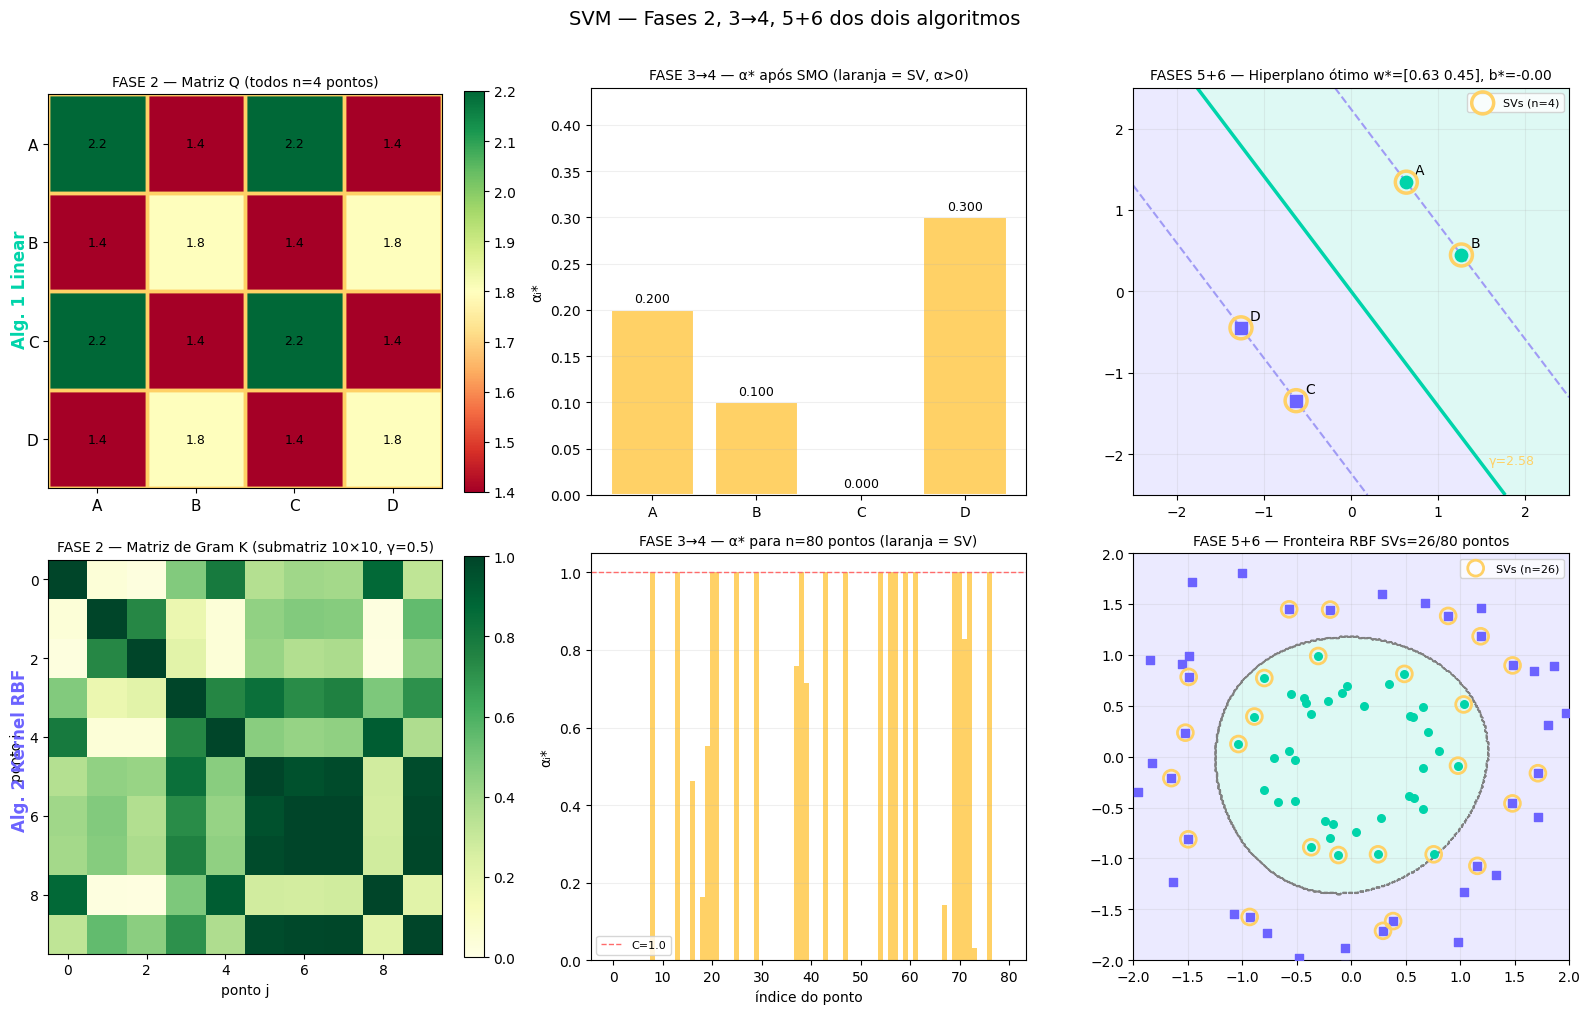

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_circles

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ══════ Linha 1: Algoritmo 1 (linear) ══════
X = np.array([[1.,2.],[2.,1.],[-1.,-1.],[-2.,0.]])
y = np.array([1.,1.,-1.,-1.])
nomes = ['A','B','C','D']
sc1 = StandardScaler(); X_sc = sc1.fit_transform(X)
clf1 = SVC(kernel='linear', C=1e6, tol=1e-8)
clf1.fit(X_sc, y)
w = clf1.coef_[0]; b = clf1.intercept_[0]
nw = np.linalg.norm(w); mg = 2/nw

# Plot 1.1: Matriz Q
ax = axes[0][0]
Q_mat = np.outer(y, y) * (X_sc @ X_sc.T)
im = ax.imshow(Q_mat, cmap='RdYlGn', vmin=Q_mat.min(), vmax=Q_mat.max())
ax.set_xticks(range(4)); ax.set_xticklabels(nomes, fontsize=11)
ax.set_yticks(range(4)); ax.set_yticklabels(nomes, fontsize=11)
for i in range(4):
    for j in range(4):
        ax.text(j, i, f'{Q_mat[i,j]:.1f}', ha='center', va='center', fontsize=9)
sv_ids = clf1.support_
for si in sv_ids:
    ax.add_patch(plt.Rectangle((si-.5,-.5), 1, 4, fill=False, ec='#ffd166', lw=2.5))
    ax.add_patch(plt.Rectangle((-.5,si-.5), 4, 1, fill=False, ec='#ffd166', lw=2.5))
ax.set_title('FASE 2 — Matriz Q (todos n=4 pontos)', fontsize=10)
plt.colorbar(im, ax=ax, fraction=0.046)

# Plot 1.2: α* após SMO
ax = axes[0][1]
alpha_all = np.zeros(4)
for k, idx in enumerate(clf1.support_):
    alpha_all[idx] = np.abs(clf1.dual_coef_.ravel()[k])
cols = ['#ffd166' if a > 1e-5 else '#444' for a in alpha_all]
bars = ax.bar(nomes, alpha_all, color=cols, edgecolor='white', linewidth=1.5)
ax.axhline(0, color='gray', lw=0.5)
for bar, a in zip(bars, alpha_all):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{a:.3f}', ha='center', va='bottom', fontsize=9)
ax.set_title('FASE 3→4 — α* após SMO (laranja = SV, α>0)', fontsize=10)
ax.set_ylabel('αᵢ*'); ax.grid(True, alpha=0.2, axis='y')
ax.set_ylim(0, max(alpha_all)*1.3 + 0.05)

# Plot 1.3: Hiperplano ótimo
ax = axes[0][2]
xx, yy = np.meshgrid(np.linspace(-2.5,2.5,300), np.linspace(-2.5,2.5,300))
Z = clf1.decision_function(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
ax.contourf(xx,yy,Z, levels=[-1e9,0,1e9], colors=['#6c63ff','#00d4aa'], alpha=0.13)
ax.contour(xx,yy,Z, levels=[-1,0,1],
           colors=['#a09bf5','#00d4aa','#a09bf5'],
           linestyles=['--','-','--'], linewidths=[1.5,2.5,1.5])
ax.scatter(X_sc[y==1,0],  X_sc[y==1,1],  c='#00d4aa', s=80, zorder=4)
ax.scatter(X_sc[y==-1,0], X_sc[y==-1,1], c='#6c63ff', marker='s', s=80, zorder=4)
ax.scatter(clf1.support_vectors_[:,0], clf1.support_vectors_[:,1],
           s=250, facecolors='none', edgecolors='#ffd166', lw=2.5, zorder=5,
           label=f'SVs (n={len(clf1.support_)})')
for i,(xi,ni) in enumerate(zip(X_sc, nomes)):
    ax.annotate(ni, xi, xytext=(xi[0]+0.1, xi[1]+0.1), fontsize=10)
# Margem anotada
x_mg = 1.5
y_top = (-w[0]*x_mg-(b+1))/w[1]; y_bot = (-w[0]*x_mg-(b-1))/w[1]
ax.annotate('', xy=(x_mg,y_top), xytext=(x_mg,y_bot),
            arrowprops=dict(arrowstyle='<->', color='#ffd166', lw=1.5))
ax.text(x_mg+0.08,(y_top+y_bot)/2, f'γ={mg:.2f}', color='#ffd166', fontsize=9)
ax.set_title(f'FASES 5+6 — Hiperplano ótimo w*={w.round(2)}, b*={b:.2f}', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
ax.set_xlim(-2.5,2.5); ax.set_ylim(-2.5,2.5)

# ══════ Linha 2: Algoritmo 2 (kernel RBF) ══════
np.random.seed(0)
X_c, y_c = make_circles(n_samples=80, noise=0.1, factor=0.4, random_state=0)
y_c = np.where(y_c==0,-1,1)
sc2 = StandardScaler(); X_cs = sc2.fit_transform(X_c)
gamma_v = 0.5
clf2 = SVC(kernel='rbf', C=1.0, gamma=gamma_v)
clf2.fit(X_cs, y_c)

def rbf_k(Xa, Xb, g):
    sq_a=np.sum(Xa**2,axis=1,keepdims=True)
    sq_b=np.sum(Xb**2,axis=1,keepdims=True).T
    return np.exp(-g*(sq_a+sq_b-2*(Xa@Xb.T)))

# Plot 2.1: Matriz de Gram (submatriz 10×10)
ax = axes[1][0]
K10 = rbf_k(X_cs[:10], X_cs[:10], gamma_v)
im2 = ax.imshow(K10, cmap='YlGn', vmin=0, vmax=1)
ax.set_title(f'FASE 2 — Matriz de Gram K (submatriz 10×10, γ={gamma_v})', fontsize=10)
plt.colorbar(im2, ax=ax, fraction=0.046)
ax.set_xlabel('ponto j'); ax.set_ylabel('ponto i')

# Plot 2.2: α* para todos os pontos
ax = axes[1][1]
alpha_all2 = np.zeros(len(X_cs))
for k,idx in enumerate(clf2.support_):
    alpha_all2[idx] = np.abs(clf2.dual_coef_.ravel()[k])
cols2 = ['#ffd166' if a>1e-5 else '#333' for a in alpha_all2]
ax.bar(range(len(alpha_all2)), alpha_all2, color=cols2, width=1.0)
ax.axhline(0, color='gray', lw=0.5)
ax.axhline(clf2.C, color='#ff6b6b', lw=1, ls='--', label=f'C={clf2.C}')
ax.set_title(f'FASE 3→4 — α* para n={len(X_cs)} pontos (laranja = SV)', fontsize=10)
ax.set_xlabel('índice do ponto'); ax.set_ylabel('αᵢ*')
ax.legend(fontsize=8); ax.grid(True, alpha=0.2, axis='y')

# Plot 2.3: Fronteira não-linear
ax = axes[1][2]
xx, yy = np.meshgrid(np.linspace(-2,2,300), np.linspace(-2,2,300))
Z2 = clf2.predict(np.c_[xx.ravel(),yy.ravel()]).reshape(xx.shape)
ax.contourf(xx,yy,Z2, levels=[-2,0,2], colors=['#6c63ff','#00d4aa'], alpha=0.13)
ax.contour(xx,yy,Z2, colors=['gray'], linewidths=0.8, linestyles='--')
ax.scatter(X_cs[y_c==1,0],  X_cs[y_c==1,1],  c='#00d4aa', s=30, zorder=4)
ax.scatter(X_cs[y_c==-1,0], X_cs[y_c==-1,1], c='#6c63ff', marker='s', s=30, zorder=4)
ax.scatter(clf2.support_vectors_[:,0], clf2.support_vectors_[:,1],
           s=130, facecolors='none', edgecolors='#ffd166', lw=2, zorder=5,
           label=f'SVs (n={len(clf2.support_)})')
ax.set_title(f'FASE 5+6 — Fronteira RBF SVs={len(clf2.support_)}/{len(X_cs)} pontos', fontsize=10)
ax.legend(fontsize=8); ax.grid(True, alpha=0.2)
ax.set_xlim(-2,2); ax.set_ylim(-2,2)

# Títulos das linhas
fig.text(0.01, 0.73, 'Alg. 1 Linear', fontsize=12, va='center',
         rotation=90, fontweight='bold', color='#00d4aa')
fig.text(0.01, 0.27, 'Alg. 2 Kernel RBF', fontsize=12, va='center',
         rotation=90, fontweight='bold', color='#6c63ff')

plt.suptitle('SVM — Fases 2, 3→4, 5+6 dos dois algoritmos', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


---

## Resumo final

```
FLUXO COMPLETO (ambos os algoritmos)

  Dados (xᵢ, yᵢ)
       │
       ▼  FASE 1 — O(n·p)
  Normalizar  →  (xᵢ − μ) / σ
       │
       ▼  FASE 2 — O(n²·p)
  Montar Q ou Gram  ←  TODOS os n pontos
       │
       ▼  FASE 3 — O(n² a n³)   ← DOMINANTE
  Resolver QP via SMO
  αᵢ sobe de 0 até convergência
       │
       ▼  FASE 4 — O(n)         ← TRIVIAL
  Varrer α*:
    αᵢ* > 0  →  SV     ← SAÍDA, não entrada
    αᵢ* = 0  →  normal (descartado)
       │
       ▼  FASE 5 — O(n_sv · p)
  Alg.1: w* = Σ αᵢyᵢxᵢ   (explícito)
  Alg.2: w* implícito em φ (nunca calculado)
  b* = média(yₛ − w*·xₛ)  para xₛ ∈ SVs_margem
       │
       ▼  FASE 6/7 — O(n_sv · p) por ponto
  Predição:
  Alg.1:  f(x) = w*·x + b*
  Alg.2:  f(x) = Σ αᵢ*yᵢ K(xᵢ, x) + b*
  ŷ = sinal(f(x)),  d = |f(x)| / ‖w*‖
```

*Pseudoalgoritmos SVM completos — baseados em libsvm/sklearn (SMO)*

---
## Referências

- [Wikipedia - Quadratic_programming](https://en.wikipedia.org/wiki/Quadratic_programming)
- [Wikipedia - SMO - Sequential minimal optimization](https://en.wikipedia.org/wiki/Sequential_minimal_optimization)
- [Youtube - SVM - Support Vector Machines: Fundamentos e prática](https://www.youtube.com/watch?v=b8nP9g0p8X4)
- [Youtube - 16. Learning: Support Vector Machines](https://www.youtube.com/watch?v=_PwhiWxHK8o)